In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from anngeno import AnnGeno
import multiprocessing

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

num_cores = multiprocessing.cpu_count()
print(num_cores)

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


16


In [2]:
# Configuration and paths
corr_method = 'pearson'
trait_type = 'quantitative'
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac


759.292

In [3]:
appv = pl.read_parquet("/home/dnanexus/data_dir/avg_pheno_per_var_quantitative_EUR_genebass1e6coding.parquet")
appv = appv.filter(pl.col('n_individuals')<=mac)
appv

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value
str,str,u32,f32,f32
"""chr1:3476029:G:A""","""red_blood_cell_erythrocyte_dis…",19,-0.347493,0.960577
"""chr1:2229460:C:T""","""red_blood_cell_erythrocyte_dis…",1,0.426851,null
"""chr1:10072146:G:A""","""red_blood_cell_erythrocyte_dis…",22,-0.12495,0.843646
"""chr1:3463318:G:A""","""mean_platelet_thrombocyte_volu…",128,-0.015066,0.846027
"""chr1:2515618:C:T""","""mean_platelet_thrombocyte_volu…",98,0.011947,0.797165
…,…,…,…,…
"""chr22:50454662:G:A""","""microalbumin_in_urine_int""",1,-0.803816,null
"""chr22:50455057:C:G""","""mothers_age_at_death_int""",1,1.928162,null
"""chr22:50283981:T:C""","""mothers_age_at_death_int""",1,1.303833,null


In [4]:
alof = pl.read_parquet("/home/dnanexus/data_dir/genebass_1e6_coding_variants.ag/annotations.parquet", columns=['id', 'region', 'loftee_hc'])
alof

id,region,loftee_hc
str,str,i8
"""chr1:169795116:G:C""","""ENSG00000000460""",0
"""chr1:169798959:G:A""","""ENSG00000000460""",0
"""chr1:169798959:G:C""","""ENSG00000000460""",0
"""chr1:169798959:G:GT""","""ENSG00000000460""",0
"""chr1:169798959:G:T""","""ENSG00000000460""",0
…,…,…
"""chr7:151061966:C:T""","""ENSG00000288608""",0
"""chr7:151061967:GA:G""","""ENSG00000288608""",1
"""chr7:151061968:A:G""","""ENSG00000288608""",0


In [5]:
alof['region'].value_counts(sort=True)

region,count
str,u64
"""ENSG00000143631""",9263
"""ENSG00000008710""",8573
"""ENSG00000081853""",8384
"""ENSG00000178209""",8265
"""ENSG00000151914""",7460
…,…
"""ENSG00000072694""",73
"""ENSG00000164032""",67
"""ENSG00000162188""",59


In [6]:
gnames = pl.read_csv('/home/dnanexus/data_dir/gnomad.v4.1.constraint_metrics.tsv',
    separator='\t',
    null_values=['.', 'NA'],
).filter(
    pl.col('transcript_type') == 'protein_coding'
).select(['gene', 'gene_id']).unique().rename({
    'gene': 'gene_name',
    'gene_id': 'region'
}).drop_nulls()

gnames

gene_name,region
str,str
"""EMB""","""ENSG00000170571"""
"""TYW1B""","""ENSG00000277149"""
"""COL4A4""","""ENSG00000081052"""
"""SYNJ2""","""ENSG00000078269"""
"""VSTM2B""","""ENSG00000187135"""
…,…
"""LRRC58""","""ENSG00000163428"""
"""OBP2A""","""ENSG00000122136"""
"""H3C4""","""ENSG00000197409"""


In [7]:
alof_gp = appv.join(alof, on='id', how='inner').join(gnames, on='region', how='left')
alof_gp

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value,region,loftee_hc,gene_name
str,str,u32,f32,f32,str,i8,str
"""chr1:3476029:G:A""","""red_blood_cell_erythrocyte_dis…",19,-0.347493,0.960577,"""ENSG00000130762""",0,"""ARHGEF16"""
"""chr1:2229460:C:T""","""red_blood_cell_erythrocyte_dis…",1,0.426851,null,"""ENSG00000157933""",0,"""SKI"""
"""chr1:10072146:G:A""","""red_blood_cell_erythrocyte_dis…",22,-0.12495,0.843646,"""ENSG00000130939""",0,"""UBE4B"""
"""chr1:3463318:G:A""","""mean_platelet_thrombocyte_volu…",128,-0.015066,0.846027,"""ENSG00000130762""",0,"""ARHGEF16"""
"""chr1:2515618:C:T""","""mean_platelet_thrombocyte_volu…",98,0.011947,0.797165,"""ENSG00000157881""",0,"""PANK4"""
…,…,…,…,…,…,…,…
"""chr22:50454662:G:A""","""microalbumin_in_urine_int""",1,-0.803816,null,"""ENSG00000100241""",0,"""SBF1"""
"""chr22:50455057:C:G""","""mothers_age_at_death_int""",1,1.928162,null,"""ENSG00000100241""",0,"""SBF1"""
"""chr22:50283981:T:C""","""mothers_age_at_death_int""",1,1.303833,null,"""ENSG00000196576""",0,"""PLXNB2"""


Pearson r: 0.33624833822250366, p-value: 2.520961276742031e-10


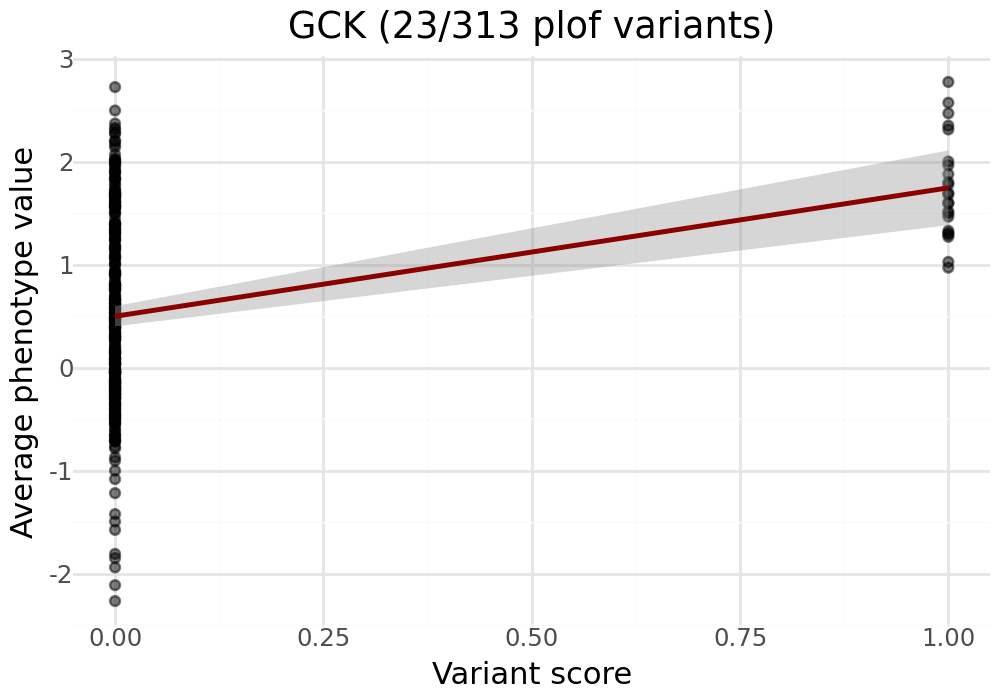

In [8]:
from scipy import stats

method = 'pearson'
gene_name = 'GCK'
phenotype = 'glycated_haemoglobin_hba1c_int'

# Filter your main dataframe
sc_df = alof_gp.filter(
    (pl.col('phenotype') == phenotype) &
    (pl.col('gene_name') == gene_name)
).drop_nulls(subset=['loftee_hc', 'mean_pheno_value'])

lof0 = sc_df.filter(pl.col('loftee_hc') == 0).shape[0]
lof1 = sc_df.filter(pl.col('loftee_hc') == 1).shape[0]

# Check if enough data remains for calculation
if len(sc_df) >= 2:
    pearson_r, pearson_p = stats.pearsonr(
        sc_df['loftee_hc'], 
        sc_df['mean_pheno_value']
    )
else:
    pearson_r, pearson_p = np.nan, np.nan

print(f"Pearson r: {pearson_r}, p-value: {pearson_p}")
# Scatter plot
(
    ggplot(sc_df, aes(x='loftee_hc', y='mean_pheno_value')) +
    geom_point(alpha=0.5) +
    geom_smooth(method='lm', se=True, color='darkred') +
    theme_minimal() +
    labs(
        x='Variant score',
        y="Average phenotype value",
        title=f"{gene_name} ({lof1}/{lof0} plof variants)"
    ) +
    theme(figure_size=(5, 3.5))
)

In [9]:
alof_gp

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value,region,loftee_hc,gene_name
str,str,u32,f32,f32,str,i8,str
"""chr1:3476029:G:A""","""red_blood_cell_erythrocyte_dis…",19,-0.347493,0.960577,"""ENSG00000130762""",0,"""ARHGEF16"""
"""chr1:2229460:C:T""","""red_blood_cell_erythrocyte_dis…",1,0.426851,null,"""ENSG00000157933""",0,"""SKI"""
"""chr1:10072146:G:A""","""red_blood_cell_erythrocyte_dis…",22,-0.12495,0.843646,"""ENSG00000130939""",0,"""UBE4B"""
"""chr1:3463318:G:A""","""mean_platelet_thrombocyte_volu…",128,-0.015066,0.846027,"""ENSG00000130762""",0,"""ARHGEF16"""
"""chr1:2515618:C:T""","""mean_platelet_thrombocyte_volu…",98,0.011947,0.797165,"""ENSG00000157881""",0,"""PANK4"""
…,…,…,…,…,…,…,…
"""chr22:50454662:G:A""","""microalbumin_in_urine_int""",1,-0.803816,null,"""ENSG00000100241""",0,"""SBF1"""
"""chr22:50455057:C:G""","""mothers_age_at_death_int""",1,1.928162,null,"""ENSG00000100241""",0,"""SBF1"""
"""chr22:50283981:T:C""","""mothers_age_at_death_int""",1,1.303833,null,"""ENSG00000196576""",0,"""PLXNB2"""


In [ ]:
# 1. Aggregate to get correlation (r) and number of pairs (n)
lofcorr_df = (
    alof_gp.lazy()
    .group_by(["region", "gene_name", "phenotype"])
    .agg(
        pl.col("id").count().alias("n_variants"),
        pl.col("loftee_hc").sum().alias("n_plof"),
        pl.corr("mean_pheno_value", "loftee_hc").alias("correlation"),
        # Add this line to count the number of non-null pairs used for the correlation
        (pl.col("mean_pheno_value").is_not_null() & pl.col("loftee_hc").is_not_null()).sum().alias("n_pairs")
    )
    .filter(pl.col("n_pairs") > 2)  # Correlation is only meaningful with >2 points
).collect(engine='streaming')

lofcorr_df

region,gene_name,phenotype,n_variants,n_plof,correlation,n_pairs
str,str,str,u64,i64,f32,u64
"""ENSG00000114126""","""TFDP2""","""arm_fat_percentage_right_int""",259,17,0.093158,259
"""ENSG00000161970""","""RPL26""","""leg_fatfree_mass_right_int""",82,1,0.046133,82
"""ENSG00000144837""","""PLA1A""","""arm_fat_mass_right_int""",346,25,-0.009018,346
"""ENSG00000142186""","""SCYL1""","""trunk_predicted_mass_int""",694,57,-0.032874,694
"""ENSG00000187210""","""GCNT1""","""neutrophill_count_int""",332,21,0.018835,332
…,…,…,…,…,…,…
"""ENSG00000170606""","""HSPA4""","""standing_height_int""",543,23,0.029097,543
"""ENSG00000197153""","""H3C12""","""triglycerides_int""",133,10,0.012556,133
"""ENSG00000142798""","""HSPG2""","""trunk_predicted_mass_int""",3823,214,-0.018124,3823


In [12]:
lofcorr_df.filter(pl.col('n_variants') != pl.col('n_pairs'))

region,gene_name,phenotype,n_variants,n_plof,correlation,n_pairs
str,str,str,u64,i64,f32,u64


In [ ]:
# 2. Compute the t-statistic and p-value on the aggregated results
if not lofcorr_df.is_empty():
    lofcorr_with_pvalue = lofcorr_df.with_columns(
        # Calculate the t-statistic from r and n
        t_stat=pl.col("correlation") * ((pl.col("n_pairs") - 2) / (1 - pl.col("correlation")**2))**0.5,
    ).with_columns(
        # Calculate the two-tailed p-value from the t-statistic
        p_value=pl.struct(["t_stat", "n_pairs"]).map_elements(
            lambda x: (
                stats.t.sf(np.abs(x["t_stat"]), df=x["n_pairs"] - 2) * 2
                if x["t_stat"] is not None else None
            ),
            return_dtype=pl.Float64
        )
    )
else:
    lofcorr_with_pvalue = lofcorr_df # Or handle empty case as needed